<a href="https://colab.research.google.com/github/mvaraujo1977/TechCahllenge_Tireoide/blob/Filomeno/model_tireoide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


In [10]:
import pandas as pd

# Carregando o dataset
df = pd.read_csv('/content/hypothyroid.data', header=None, na_values='?')

print("Dataset carregado com sucesso!")
print(f"Formato do dataset: {df.shape}")
print(df.head())

Dataset carregado com sucesso!
Formato do dataset: (3163, 26)
            0     1  2  3  4  5  6  7  8  9   ... 16   17 18    19 20    21  \
0  hypothyroid  72.0  M  f  f  f  f  f  f  f  ...  y  0.6  y  15.0  y  1.48   
1  hypothyroid  15.0  F  t  f  f  f  f  f  f  ...  y  1.7  y  19.0  y  1.13   
2  hypothyroid  24.0  M  f  f  f  f  f  f  f  ...  y  0.2  y   4.0  y  1.00   
3  hypothyroid  24.0  F  f  f  f  f  f  f  f  ...  y  0.4  y   6.0  y  1.04   
4  hypothyroid  77.0  M  f  f  f  f  f  f  f  ...  y  1.2  y  57.0  y  1.28   

  22    23 24  25  
0  y  10.0  n NaN  
1  y  17.0  n NaN  
2  y   0.0  n NaN  
3  y   6.0  n NaN  
4  y  44.0  n NaN  

[5 rows x 26 columns]


In [12]:
import re
import os

names_file = 'hypothyroid.names'

column_names = []

if os.path.exists(names_file):
    with open(names_file, 'r') as f:
        lines = f.readlines()

    # Tenta encontrar a linha que define as classes (primeira coluna)
    # No dataset hypothyroid, a primeira coluna geralmente é o alvo
    column_names.append('target')

    # Procura por padrões como 'nome_da_coluna: tipo.' no arquivo .names
    for line in lines:
        match = re.search(r'^([a-zA-Z0-9_ \-]+):', line)
        if match:
            col_name = match.group(1).strip().replace(' ', '_')
            if col_name not in column_names:
                column_names.append(col_name)

# Se conseguimos extrair nomes, aplicamos ao dataframe
if len(column_names) == len(df.columns):
    df.columns = column_names
    print("Nomes das colunas aplicados com sucesso!")

display(df.head())
df.describe()

Nomes das colunas aplicados com sucesso!


,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,0.6,y,15.0,y,1.48,y,10.0,n,NaN
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,1.7,y,19.0,y,1.13,y,17.0,n,NaN
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.2,y,4.0,y,1.00,y,0.0,n,NaN
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,0.4,y,6.0,y,1.04,y,6.0,n,NaN
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,57.0,y,1.28,y,44.0,n,NaN


,age,TSH,T3,TT4,T4U,FTI,TBG
count,2717.000000,2695.000000,2468.000000,2914.000000,2915.000000,2916.000000,260.000000
mean,51.154214,5.923180,1.939749,108.850000,0.978199,115.397771,31.283077
std,19.294405,23.899467,0.996773,45.485419,0.226580,60.239572,19.224659
min,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,35.000000,0.000000,1.400000,83.000000,0.850000,91.000000,21.000000
50%,54.000000,0.700000,1.800000,104.000000,0.960000,107.000000,28.000000
75%,67.000000,2.300000,2.300000,128.000000,1.065000,129.000000,34.000000
max,98.000000,530.000000,10.200000,450.000000,2.210000,881.000000,122.000000


In [ ]:
from google.colab import files

# Nome do arquivo de saída
output_filename = 'hypothyroid_final.csv'

# Salva o dataframe como CSV
df.to_csv(output_filename, index=False)

print(f'Arquivo {output_filename} gerado com sucesso! Iniciando download...')

# Faz o download do arquivo para o seu computador
files.download(output_filename)

Arquivo hypothyroid_final.csv gerado com sucesso! Iniciando download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
df.groupby('target').describe()

age                                                      \
              count       mean        std  min    25%   50%   75%   max   
target                                                                    
hypothyroid   136.0  54.294118  19.809507  5.0  40.75  59.5  71.0  88.0   
negative     2581.0  50.988764  19.256617  1.0  34.00  54.0  67.0  98.0   

                TSH             ...    FTI           TBG             \
              count       mean  ...    75%    max  count       mean   
target                          ...                                   
hypothyroid   150.0  63.638667  ...   51.0  133.0    3.0  30.000000   
negative     2545.0   2.521481  ...  131.0  881.0  257.0  31.298054   

                                                       
                   std   min   25%   50%   75%    max  
target                                                 
hypothyroid   3.464102  28.0  28.0  28.0  31.0   34.0  
negative     19.334046   0.0  21.0  28.0  34.0  122.0  

[2 rows x 56 columns]

In [14]:
#Verificando inconsistências
df.isnull().sum()

,0
target,0
age,446
sex,73
on_thyroxine,0
query_on_thyroxine,0
on_antithyroid_medication,0
thyroid_surgery,0
query_hypothyroid,0
query_hyperthyroid,0
pregnant,0


<Axes: >

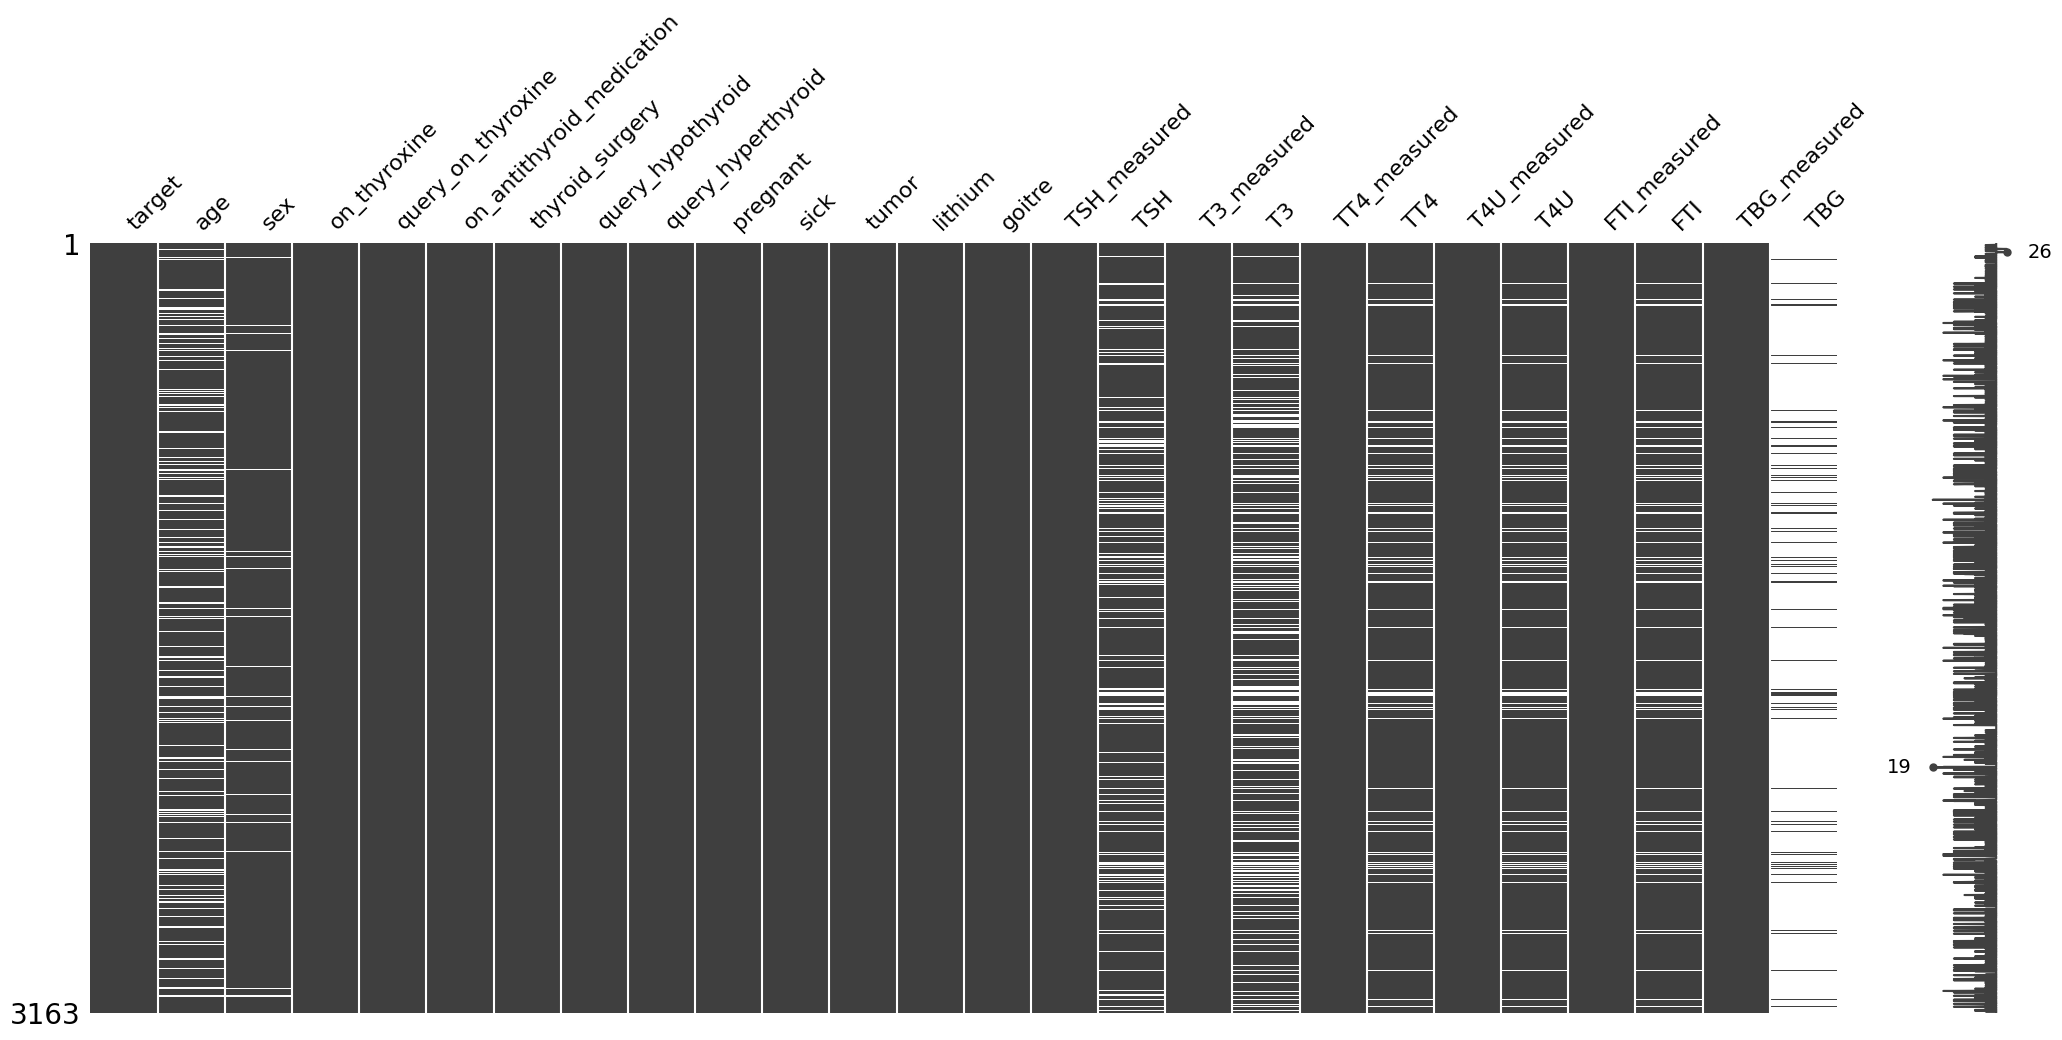

In [15]:
#Observando valores nulos
import missingno as msno
msno.matrix(df)